# Module 07 — Cell Type Annotation

This notebook visualizes cell type annotation results from
`scripts/07_annotation.py`. After integration (Module 05) and Leiden
clustering (Module 06), de novo annotation is performed using IVD-specific
marker gene signatures, with CellTypist validation for non-mesenchymal subtypes.

**Sections**
- §1–§5 — v5 atlas (CCA-flat, status: completed 2026-03-25)
- §6 — tiered v4 atlas (status: Module 07 complete 2026-05-15; pending human checkpoint)

**v5 cell-type counts:** NP 5 · AF 4 · CEP 7 · all_cells 16

**Tiered v4 cell-type counts (2026-05-15 reruns):** NP 8 · AF 7 · CEP 6 · all_cells 19

**Data sources**
- v5: `data/integrated/{NP,AF,CEP,all_cells}.h5ad` · `results/integration/`
- tiered v4: `data/integrated/tiered_v4/{NP,AF,CEP,all_cells}.h5ad` · `results/integration/tiered_v4/`


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='scanpy')

import io
from pathlib import Path

import anndata
anndata.settings.allow_write_nullable_strings = True

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from PIL import Image as PILImage
from IPython.display import Image, display, Markdown

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# JPEG-compression helpers — keep notebook under GitHub's ~10 MB render limit.
# Source figures stay full-resolution in results/.
UMAP_MAX_WIDTH = 1500
UMAP_JPEG_QUALITY = 88

def _encode_jpeg(img, max_width=UMAP_MAX_WIDTH, quality=UMAP_JPEG_QUALITY):
    img = img.convert('RGB')
    if img.width > max_width:
        ratio = max_width / img.width
        img = img.resize((max_width, int(img.height * ratio)), PILImage.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality, optimize=True)
    return buf.getvalue()

def show_png_as_jpeg(path, width=UMAP_MAX_WIDTH):
    """Load a PNG from disk, re-encode as compressed JPEG for notebook embed."""
    jpeg_bytes = _encode_jpeg(PILImage.open(str(path)))
    display(Image(data=jpeg_bytes, format='jpeg'))

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
INT_DIR = BASE / 'data' / 'integrated'
RESULTS_DIR = BASE / 'results' / 'integration'
DOTPLOT_DIR = RESULTS_DIR / 'annotation_dotplots'
MARKER_DIR = RESULTS_DIR / 'cluster_markers'
CELLTYPIST_DIR = RESULTS_DIR / 'celltypist_validation'

COMPARTMENTS = {
    'NP': INT_DIR / 'NP.h5ad',
    'AF': INT_DIR / 'AF.h5ad',
    'CEP': INT_DIR / 'CEP.h5ad',
}

for name, path in COMPARTMENTS.items():
    print(f'  {name}: {"found" if path.exists() else "NOT FOUND"}')

  NP: found
  AF: found
  CEP: found


## §1 — Cell Type Definitions (v5)

The table below shows all annotated cell types with their defining markers,
cluster assignments, and confidence distributions.

In [2]:
# Load and display cell type definitions
ct_def_path = RESULTS_DIR / 'cell_type_definitions.tsv'
if ct_def_path.exists():
    ct_defs = pd.read_csv(ct_def_path, sep='\t')
    display(ct_defs.style.set_caption('Cell Type Definitions — All Compartments'))
else:
    print('Cell type definitions file not found')

,object,cell_type,coarse_cell_type,n_cells,clusters,canonical_markers,confidence_distribution
0,NP,Endothelial,Endothelial,2645,"NM0,NM1,NM4","PECAM1,VWF,CDH5",high=1381; medium=1264
1,NP,Macrophage_M2,Macrophage,181,NM3,"CD163,MRC1,MSR1,TGFB1",high=181; medium=0
2,NP,NP_fibrocartilaginous,Fibroblast_like,73764,"M2,M3,M4,M5","COL1A1,COL2A1,VCAN",high=73764; medium=0
3,NP,NP_mature_chondrocyte,Chondrocyte_like,185794,"M0,M1,M6","ACAN,COL2A1,SOX9,COMP,PRG4",high=185794; medium=0
4,NP,T_cell_CD8,T_cell,583,NM2,"CD8A,CD8B,GZMB,PRF1",medium=583; high=0
5,AF,AF_inner,Chondrocyte_like,32839,"M0,M8,M9","COL2A1,ACAN,SOX9",high=32839
6,AF,AF_outer,Fibroblast_like,51729,"M1,M2,M3,M4,M5,M6,M7","COL1A1,COL1A2,THY1,DCN,LUM",high=51729
7,AF,Endothelial,Endothelial,22,NM1,"PECAM1,VWF,CDH5",high=22
8,AF,Macrophage_M2,Macrophage,34,NM0,"CD163,MRC1,MSR1,TGFB1",high=34
9,CEP,EP_hyaline,Chondrocyte_like,12597,M1,"COL2A1,COL10A1,SOX9",high=12597; medium=0


## §2 — Annotated UMAPs per Compartment (v5)

UMAP colored by final `cell_type` annotation for each compartment.

### NP — Annotated UMAP

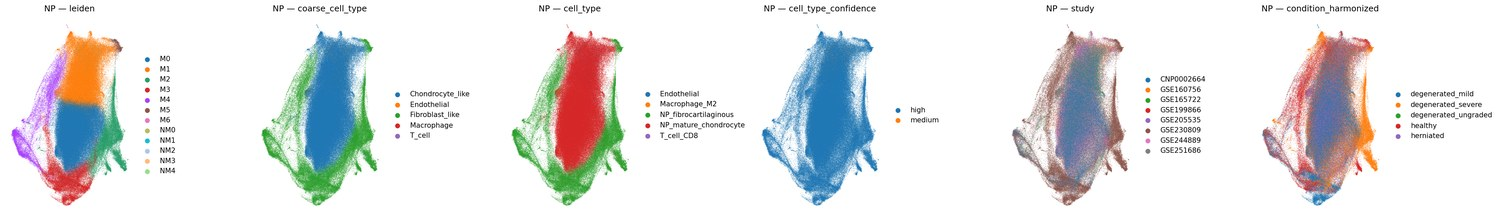

### AF — Annotated UMAP

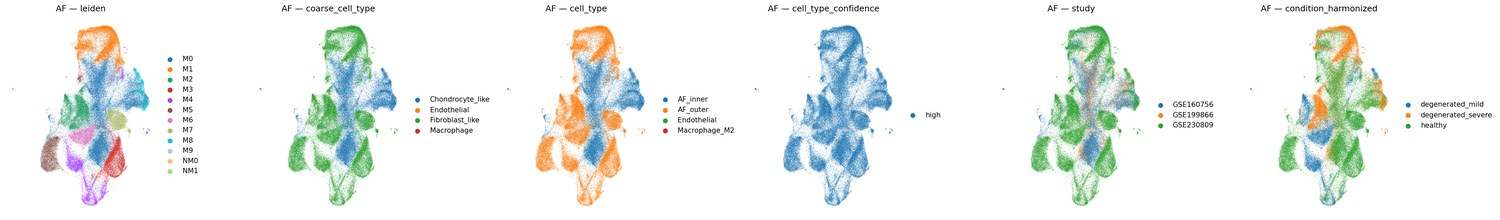

### CEP — Annotated UMAP

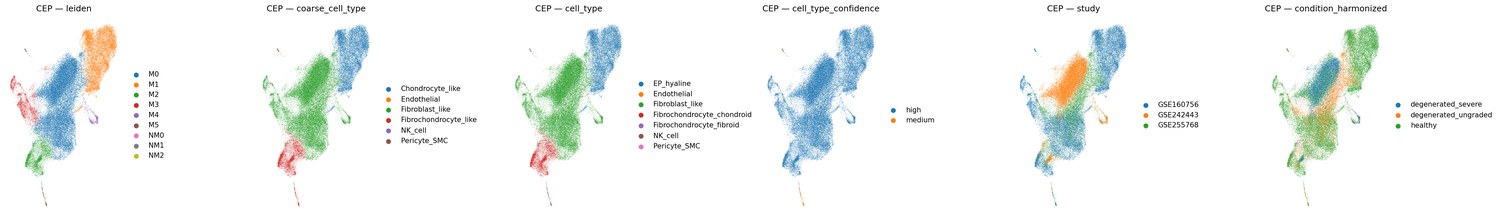

### all_cells — Annotated UMAP

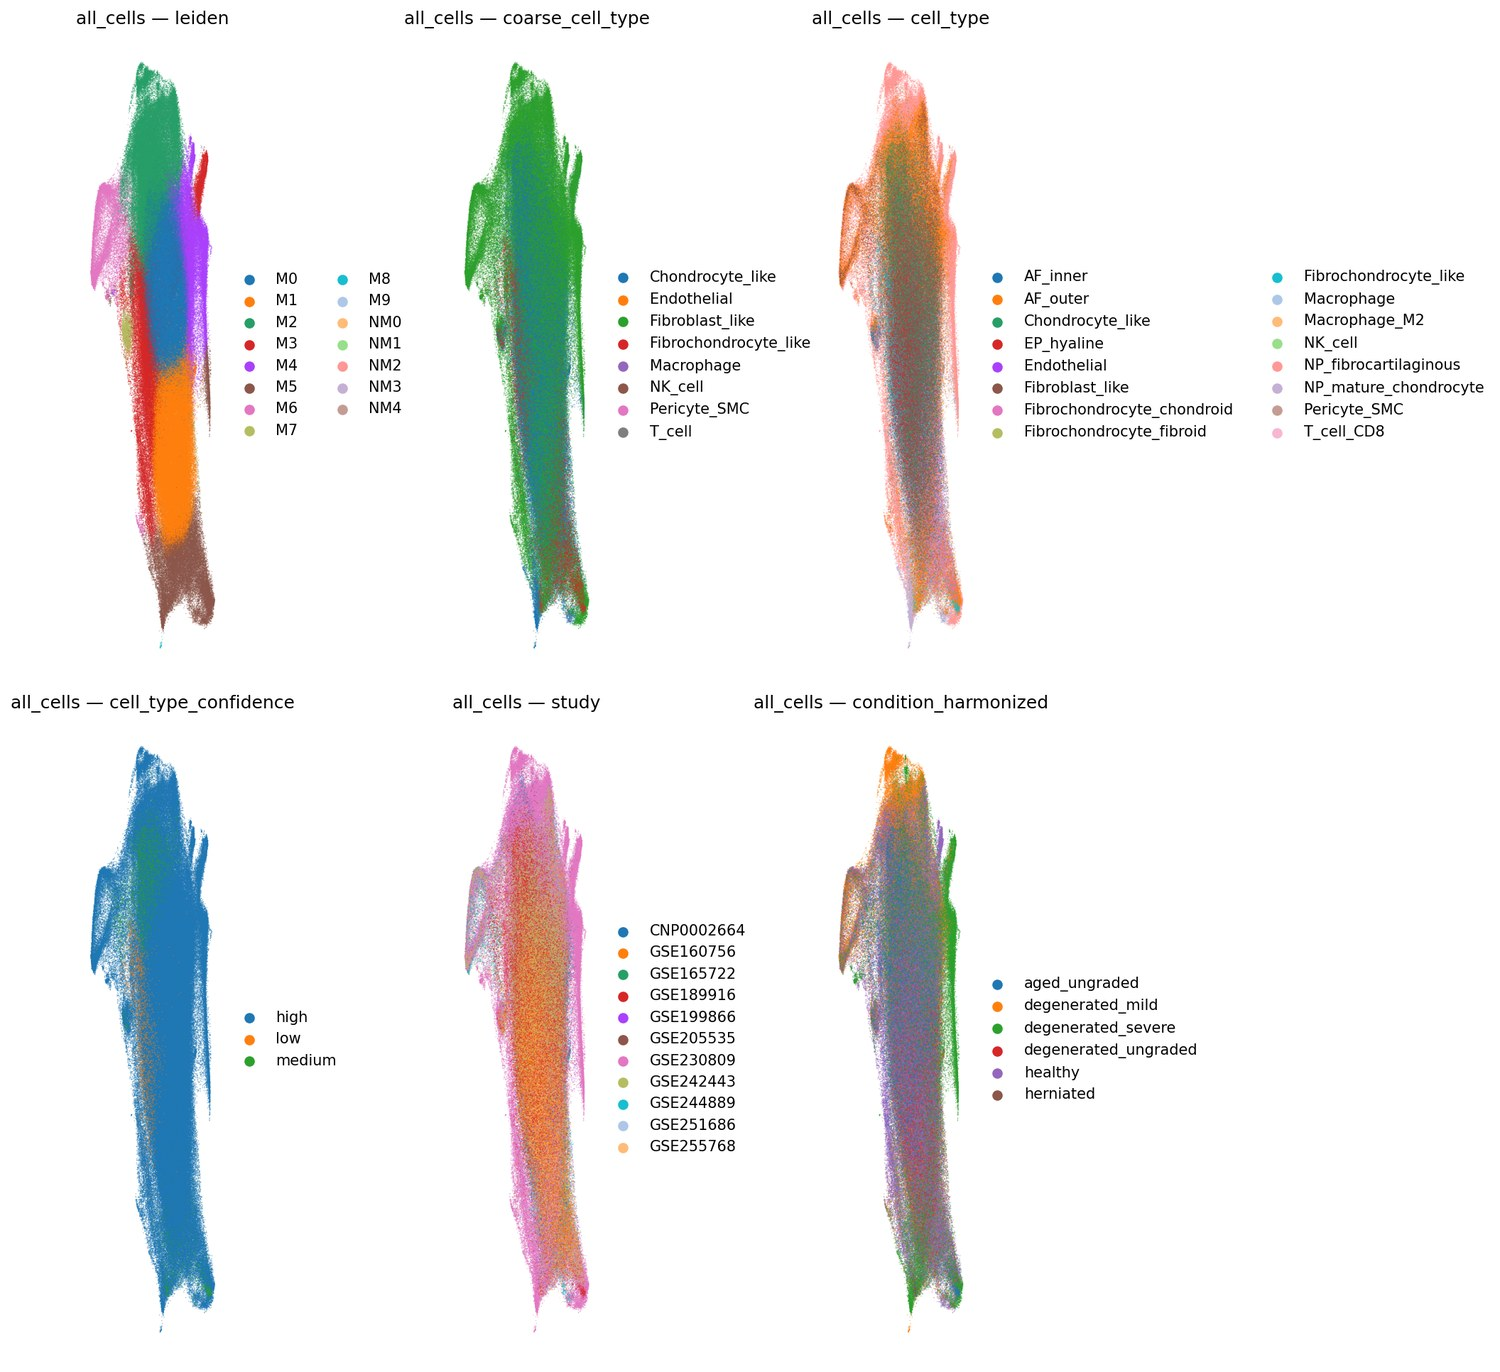

In [3]:
# Display pre-generated annotated UMAP images (re-encoded as JPEG to control notebook size)
for comp in ['NP', 'AF', 'CEP', 'all_cells']:
    umap_path = RESULTS_DIR / f'umap_{comp}_annotated.png'
    if umap_path.exists():
        display(Markdown(f'### {comp} — Annotated UMAP'))
        show_png_as_jpeg(umap_path)
    else:
        umap_basic = RESULTS_DIR / f'umap_{comp}.png'
        if umap_basic.exists():
            display(Markdown(f'### {comp} — UMAP'))
            show_png_as_jpeg(umap_basic)
        else:
            print(f'No UMAP image for {comp}')

## §3 — Marker Expression Dot Plots (v5)

Dot plots show expression of canonical markers per cell type. Dot size
represents fraction of cells expressing the gene; color intensity represents
mean expression level.

Annotation dot plots: 9 PDF files
  AF_all_markers_canonical_markers.pdf
  AF_mesenchymal_coarse_canonical_markers.pdf
  AF_non_mesenchymal_coarse_canonical_markers.pdf
  CEP_all_markers_canonical_markers.pdf
  CEP_mesenchymal_coarse_canonical_markers.pdf
  CEP_non_mesenchymal_coarse_canonical_markers.pdf
  NP_all_markers_canonical_markers.pdf
  NP_mesenchymal_coarse_canonical_markers.pdf
  NP_non_mesenchymal_coarse_canonical_markers.pdf

Generating marker dot plots from integrated objects...


### NP — Canonical Marker Expression

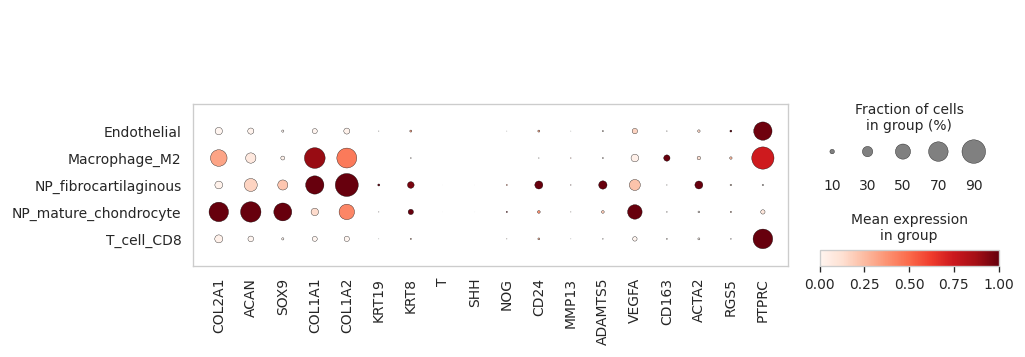

### AF — Canonical Marker Expression

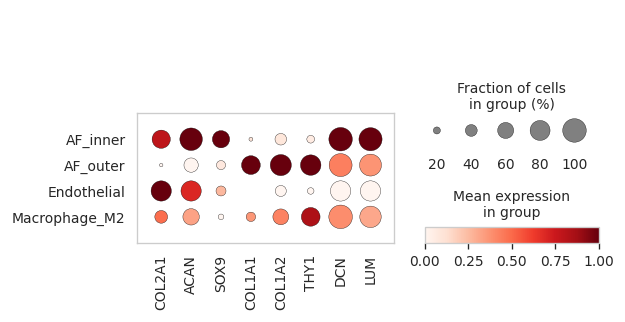

### CEP — Canonical Marker Expression

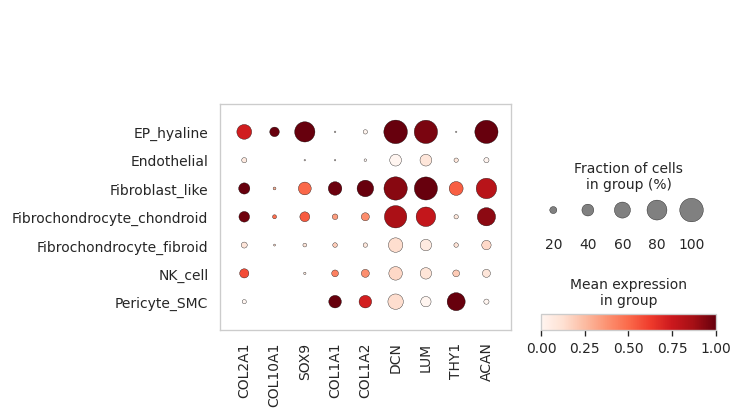

In [4]:
# List available annotation dot plots
dotplot_files = sorted(DOTPLOT_DIR.glob('*.pdf'))
print(f'Annotation dot plots: {len(dotplot_files)} PDF files')
for f in dotplot_files:
    print(f'  {f.name}')

# Note: PDF dot plots cannot be embedded directly in notebooks.
# They are available in results/integration/annotation_dotplots/ for review.
# Instead, show marker expression from the integrated objects directly.

print('\nGenerating marker dot plots from integrated objects...')

MARKERS_PER_COMP = {
    'NP': ['COL2A1', 'ACAN', 'SOX9', 'COL1A1', 'COL1A2', 'KRT19', 'KRT8',
           'T', 'SHH', 'NOG', 'CD24', 'MMP13', 'ADAMTS5', 'VEGFA',
           'CD163', 'ACTA2', 'RGS5', 'PTPRC'],
    'AF': ['COL2A1', 'ACAN', 'SOX9', 'COL1A1', 'COL1A2', 'THY1', 'DCN', 'LUM'],
    'CEP': ['COL2A1', 'COL10A1', 'SOX9', 'COL1A1', 'COL1A2', 'DCN', 'LUM', 'THY1', 'ACAN'],
}

for comp_name, comp_path in COMPARTMENTS.items():
    if not comp_path.exists():
        continue
    markers = MARKERS_PER_COMP.get(comp_name, [])
    if not markers:
        continue

    adata = sc.read_h5ad(comp_path)
    if 'cell_type' not in adata.obs.columns:
        del adata
        continue

    available = [g for g in markers if g in adata.var_names]
    if not available:
        del adata
        continue

    display(Markdown(f'### {comp_name} — Canonical Marker Expression'))
    sc.pl.dotplot(adata, var_names=available, groupby='cell_type',
                  standard_scale='var', show=True)
    del adata

## §4 — Annotation Confidence (v5)

Distribution of annotation confidence levels (high/medium/low) across cell
types, showing how confidently each cell type was assigned.

In [5]:
# Load annotation confidence from integrated objects
for comp_name, comp_path in COMPARTMENTS.items():
    if not comp_path.exists():
        continue
    adata = sc.read_h5ad(comp_path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    adata.file.close()

    if 'cell_type' not in obs_df.columns:
        continue

    display(Markdown(f'### {comp_name} — Cell Type Summary'))

    # Cell type counts
    ct_counts = obs_df['cell_type'].value_counts()
    print(f'{comp_name}: {len(obs_df):,} cells, {ct_counts.shape[0]} cell types')
    print(ct_counts.to_string())
    print()

    # Confidence distribution if available
    if 'cell_type_confidence' in obs_df.columns:
        conf_ct = pd.crosstab(obs_df['cell_type'], obs_df['cell_type_confidence'])
        display(conf_ct.style.set_caption(f'{comp_name} — Confidence per Cell Type'))

    del obs_df

### NP — Cell Type Summary

NP: 262,967 cells, 5 cell types
cell_type
NP_mature_chondrocyte    185794
NP_fibrocartilaginous     73764
Endothelial                2645
T_cell_CD8                  583
Macrophage_M2               181



cell_type_confidence,high,medium
cell_type,,
Endothelial,1381,1264
Macrophage_M2,181,0
NP_fibrocartilaginous,73764,0
NP_mature_chondrocyte,185794,0
T_cell_CD8,0,583


### AF — Cell Type Summary

AF: 84,624 cells, 4 cell types
cell_type
AF_outer         51729
AF_inner         32839
Macrophage_M2       34
Endothelial         22



cell_type_confidence,high
cell_type,
AF_inner,32839
AF_outer,51729
Endothelial,22
Macrophage_M2,34


### CEP — Cell Type Summary

CEP: 50,858 cells, 7 cell types
cell_type
Fibroblast_like               33582
EP_hyaline                    12597
Fibrochondrocyte_chondroid     4292
Fibrochondrocyte_fibroid        298
Endothelial                      38
Pericyte_SMC                     30
NK_cell                          21



cell_type_confidence,high,medium
cell_type,,
EP_hyaline,12597,0
Endothelial,38,0
Fibroblast_like,33582,0
Fibrochondrocyte_chondroid,4292,0
Fibrochondrocyte_fibroid,0,298
NK_cell,21,0
Pericyte_SMC,30,0


## §5 — CellTypist Validation (v5)

CellTypist concordance tables comparing de novo annotations with automated
predictions for non-mesenchymal cell types.

In [6]:
# Load CellTypist concordance tables
concordance_files = sorted(CELLTYPIST_DIR.glob('*_concordance.tsv'))

if concordance_files:
    for f in concordance_files:
        comp = f.stem.replace('_concordance', '')
        df = pd.read_csv(f, sep='\t')
        display(Markdown(f'### {comp} CellTypist Concordance'))
        display(df)

        # Summary: fraction concordant
        n_concordant = df['concordant'].sum() if 'concordant' in df.columns else 0
        n_total = len(df)
        print(f'  Concordant clusters: {n_concordant}/{n_total} '
              f'({n_concordant/n_total*100:.0f}%)')
else:
    print('No CellTypist concordance files found')

### AF CellTypist Concordance

,cluster,n_cells,de_novo_label,celltypist_majority,celltypist_agreement_pct,concordant
0,0,34,Macrophage_M2,Fibroblasts,38.2,False
1,1,22,Endothelial,Endothelial cells,95.5,True


  Concordant clusters: 1/2 (50%)


### CEP CellTypist Concordance

,cluster,n_cells,de_novo_label,celltypist_majority,celltypist_agreement_pct,concordant
0,0,38,Endothelial,Endothelial cells,100.0,True
1,1,30,Pericyte_SMC,NK cells,76.7,False
2,2,21,NK_cell,Classical monocytes,52.4,False


  Concordant clusters: 1/3 (33%)


### NP CellTypist Concordance

,cluster,n_cells,de_novo_label,celltypist_majority,celltypist_agreement_pct,concordant
0,0,1277,Endothelial,Endothelial cells,43.8,True
1,1,1264,Endothelial,Classical monocytes,67.9,False
2,2,583,T_cell_CD8,Classical monocytes,46.3,False
3,3,181,Macrophage_M2,Macrophages,72.4,True
4,4,104,Endothelial,Endothelial cells,65.4,True


  Concordant clusters: 3/5 (60%)


## Status — v5 complete (2026-03-25)

### Summary
- De novo cell type annotation using IVD-specific marker gene signatures
- CellTypist validation for non-mesenchymal subtypes (Immune_All_Low model)
- NP: 5 cell types, AF: 4 cell types, CEP: 7 cell types
- Annotation confidence tracked via `cell_type_confidence` column
- Results stored in `cell_type` column of integrated objects

### Next steps
- Module 08: Pseudobulk differential expression analysis (healthy vs degenerated)
- Module 09: Biological interpretation (pathway enrichment, TF activity)
- Module 10: Trajectory/pseudotime analysis
- Module 11: Cell-cell communication

## §6 — Tiered v4 Atlas (2026-05-22 — NP unassigned rescue + Module 04 propagation)

Annotation results from the tiered v4 pipeline after the end-to-end rerun on
2026-05-22. Three changes since the 2026-05-15 baseline:

1. **NP unassigned rescue (commit `15944f1`)** — Module 04 cell-class panels
   extended for neutrophils, plasma cells, erythrocytes; Module 07 non-mes
   coarse panels extended in parallel. Net effect on tier sizes:
   non-mes grew NP 3,393 → 75,667 cells; AF 56 → 12,012; CEP 71 → 13,975;
   all_cells 3,464 → 101,747.
2. **CellTypist `.X` normalization patch (this rerun)** — `validate_immune_with_celltypist()`
   now builds a CP10K + log1p copy of the non-mes subset before handing it to
   `celltypist.annotate()`. The 2026-05-15 hard failure on CEP non-mes (`Invalid
   expression matrix in .X`) is resolved; CellTypist runs cleanly on all three
   non-mes tiers.
3. **Module 04 → Module 07 label propagation (this rerun)** — `annotate_coarse()`
   for the non-mes tier now falls back to Module 04's per-cell `coarse_label`
   majority (≥60% threshold) when per-cluster panel scoring on rank_genes_groups
   markers fails to fire. This catches:
   - Naive/resting lymphocyte clusters dominated by ribosomal genes (NP cluster 1,
     AF cluster 0) → labeled `Immune`
   - Tier-wide RBC contamination where hemoglobin genes don't appear as cluster-
     distinguishing markers (CEP clusters 0–4, AF cluster 5) → labeled `Erythrocyte`

Wall time: ~32 min (28 min compartments + 3.5 min `all_cells`-only resume after a
Categorical-assignment bug surfaced in `process_all_cells_secondary` and was
patched). Validator overall status: **PASSED**.

**Cell type counts (2026-05-22):** NP 10 · AF 7 · CEP 7 · all_cells 18
**Unassigned %:** 0.0 % across all four compartments (was 12.4 / 0.0 / 0.0 / 0.0 on 2026-05-15, then 6.6 / 6.5 / 24.7 / 0.0 on the 2026-05-22 v1 pre-propagation run)

**Data sources**
- `data/integrated/tiered_v4/{NP,AF,CEP,all_cells}.h5ad` — annotated objects
- `results/integration/tiered_v4/cell_type_definitions.tsv` — cell-type marker definitions
- `results/integration/tiered_v4/umap_{NP,AF,CEP,all_cells}_annotated.png`
- `results/integration/tiered_v4/cluster_markers/` — per-tier and within-coarse marker tables
- `results/integration/tiered_v4/annotation_dotplots/` — marker dot plots


In [7]:
# ── tiered_v4 paths ────────────────────────────────────────────────────────
TV4_INT_DIR = BASE / 'data' / 'integrated' / 'tiered_v4'
TV4_RESULTS_DIR = BASE / 'results' / 'integration' / 'tiered_v4'
TV4_DOTPLOT_DIR = TV4_RESULTS_DIR / 'annotation_dotplots'
TV4_MARKER_DIR = TV4_RESULTS_DIR / 'cluster_markers'
TV4_CELLTYPIST_DIR = TV4_RESULTS_DIR / 'celltypist_validation'

TV4_COMPARTMENTS = {
    'NP':  TV4_INT_DIR / 'NP.h5ad',
    'AF':  TV4_INT_DIR / 'AF.h5ad',
    'CEP': TV4_INT_DIR / 'CEP.h5ad',
    'all_cells': TV4_INT_DIR / 'all_cells.h5ad',
}

for name, path in TV4_COMPARTMENTS.items():
    print(f'  {name}: {"found" if path.exists() else "NOT FOUND"}')


  NP: found
  AF: found
  CEP: found
  all_cells: found


### §6a — Cell Type Definitions (tiered v4)

Cell-type definitions across the four objects, with the contributing cluster
IDs, canonical markers, and confidence breakdown for each type. Cells labeled
`Immune` via Module 04 propagation have `confidence_distribution` showing the
`medium` confidence tag and `annotation_evidence = Module04_majority=Immune(XX%)`.


In [8]:
tv4_ct_def_path = TV4_RESULTS_DIR / 'cell_type_definitions.tsv'
if tv4_ct_def_path.exists():
    tv4_ct_defs = pd.read_csv(tv4_ct_def_path, sep='\t')
    display(tv4_ct_defs.style.set_caption('Tiered v4 — Cell Type Definitions (all compartments)'))
else:
    print('tiered_v4 cell type definitions file not found')


,object,cell_type,coarse_cell_type,n_cells,n_subtypes,subtypes,confidence_distribution
0,NP,Endothelial,Endothelial,2439,1,Endothelial,high=2439; medium=0
1,NP,Erythrocyte,Erythrocyte,3489,1,Erythrocyte,high=3489; medium=0
2,NP,Immune,Immune,17282,1,Immune,medium=17282; high=0
3,NP,Macrophage_M1,Macrophage,3500,1,Macrophage_M1,high=3500; medium=0
4,NP,Macrophage_M2,Macrophage,20362,1,Macrophage_M2,medium=20362; high=0
5,NP,NP_fibrocartilaginous,Fibroblast_like,94597,6,"NP_fibrocartilaginous_endothelial_admixed, NP_fibrocartilaginous_inflammatory, NP_fibrocartilaginous_matrix_active, NP_fibrocartilaginous_migratory, NP_fibrocartilaginous_proliferating, NP_fibrocartilaginous_stressed",high=81514; medium=13083
6,NP,NP_fibrochondrocyte_chondroid,Fibrochondrocyte_like,59650,1,NP_fibrochondrocyte_chondroid_homeostatic,high=59650; medium=0
7,NP,NP_mature_chondrocyte,Chondrocyte_like,33010,1,NP_mature_chondrocyte_matrix_active,high=33010; medium=0
8,NP,Neutrophil,Neutrophil,27880,1,Neutrophil,high=27880; medium=0
9,NP,Pericyte_SMC,Pericyte_SMC,715,1,Pericyte_SMC,medium=715; high=0


### §6b — Annotated UMAPs per Compartment-Tier (tiered v4)

UMAPs colored by final `cell_type` annotation. Each compartment is shown as
two side-by-side panels — mesenchymal and non-mesenchymal — because the tier-
specific clustering uses tier-specific embeddings (stored as NaN-padded
`X_umap` in the h5ad). This is the same layout as `notebooks/06_clustering.ipynb`
§5d, just colored by `cell_type` instead of cluster ID. Cell counts in the
title reflect cells with a valid (non-NaN) UMAP for that tier.


#### NP

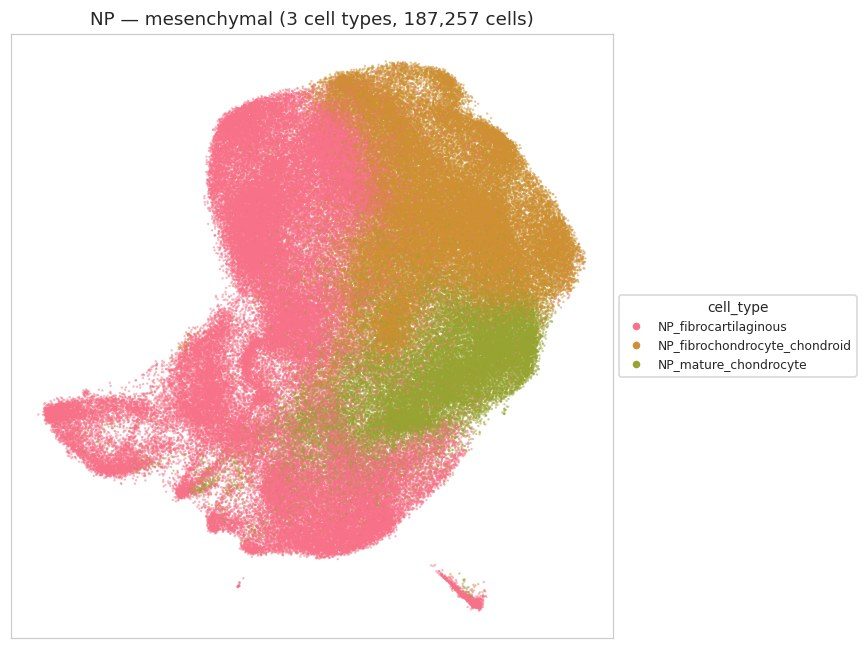

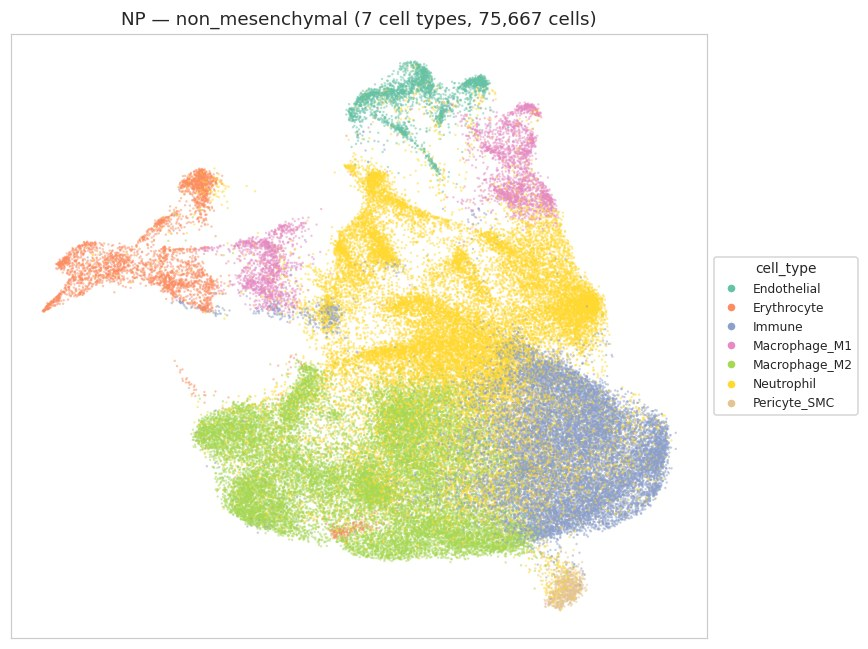

#### AF

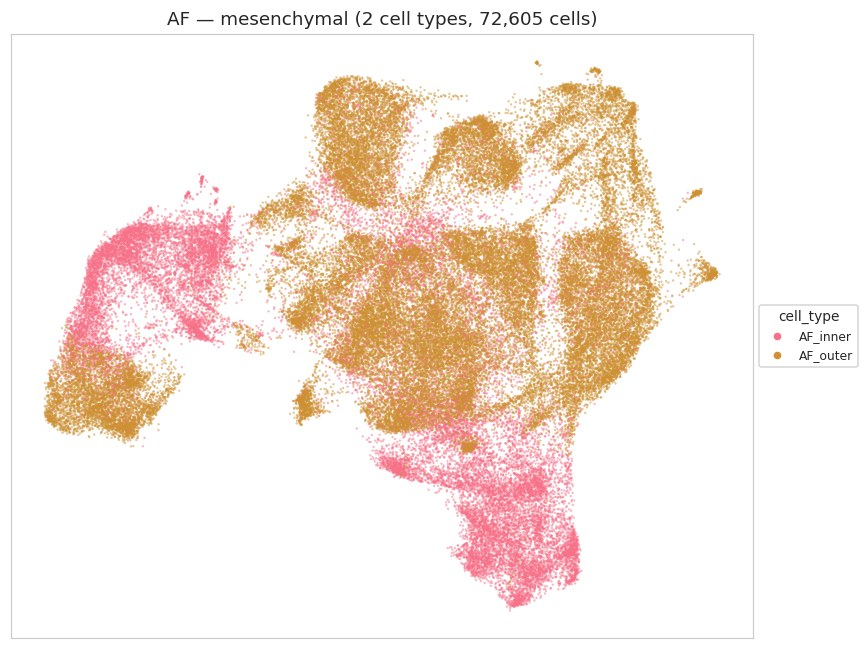

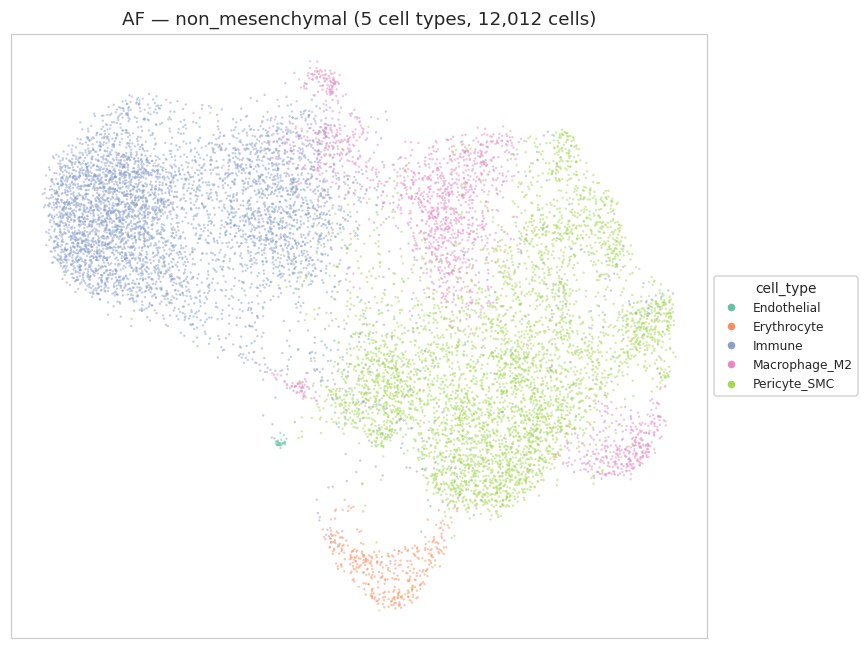

#### CEP

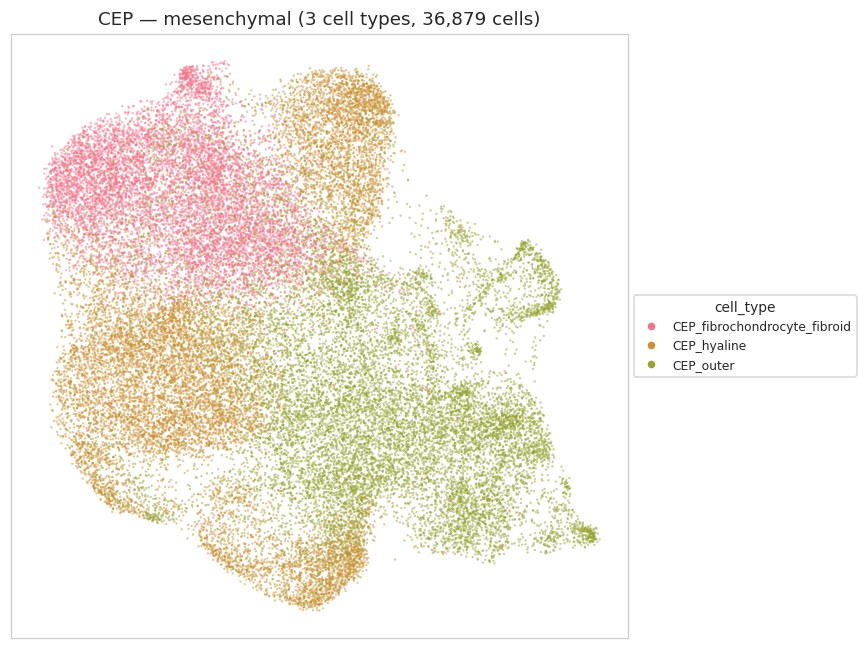

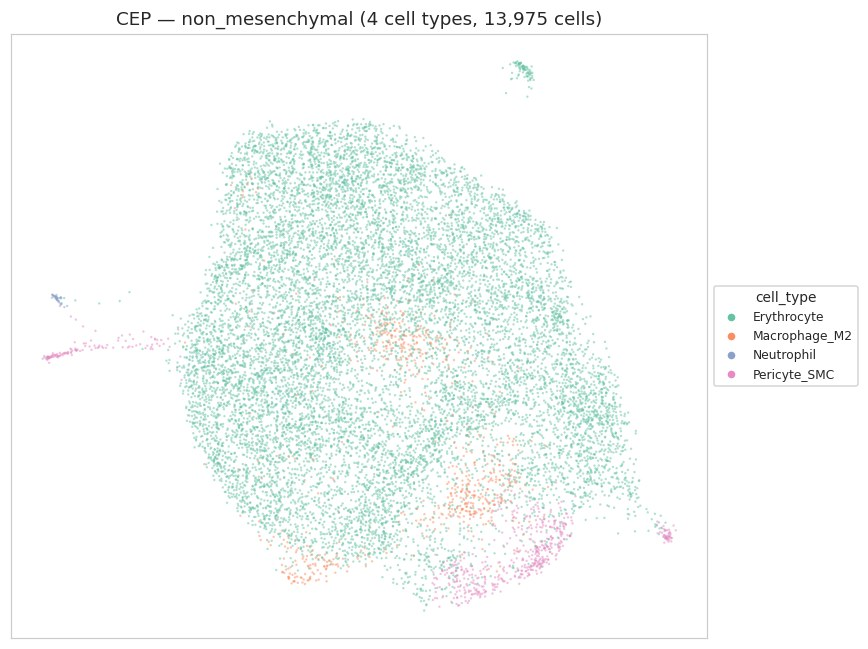

#### all_cells

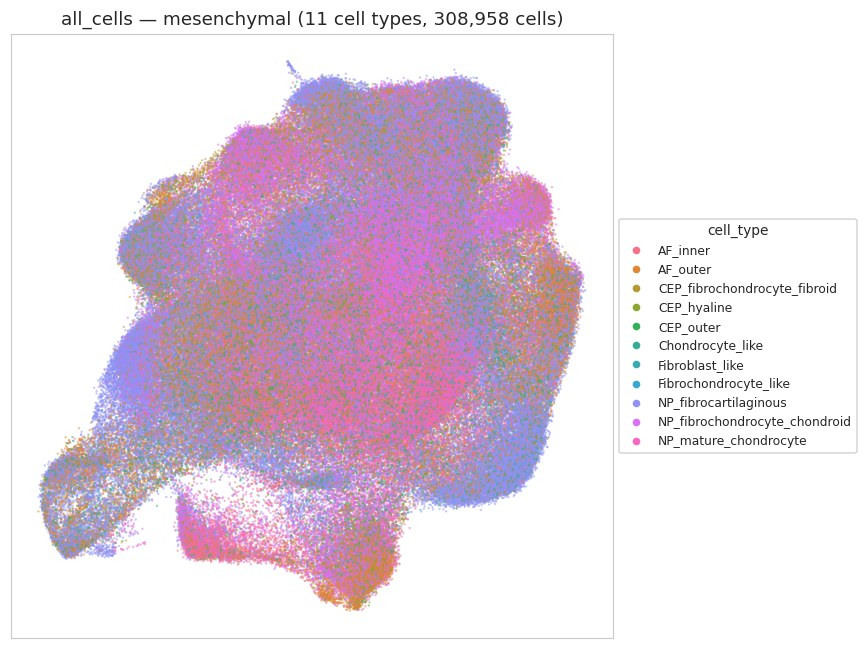

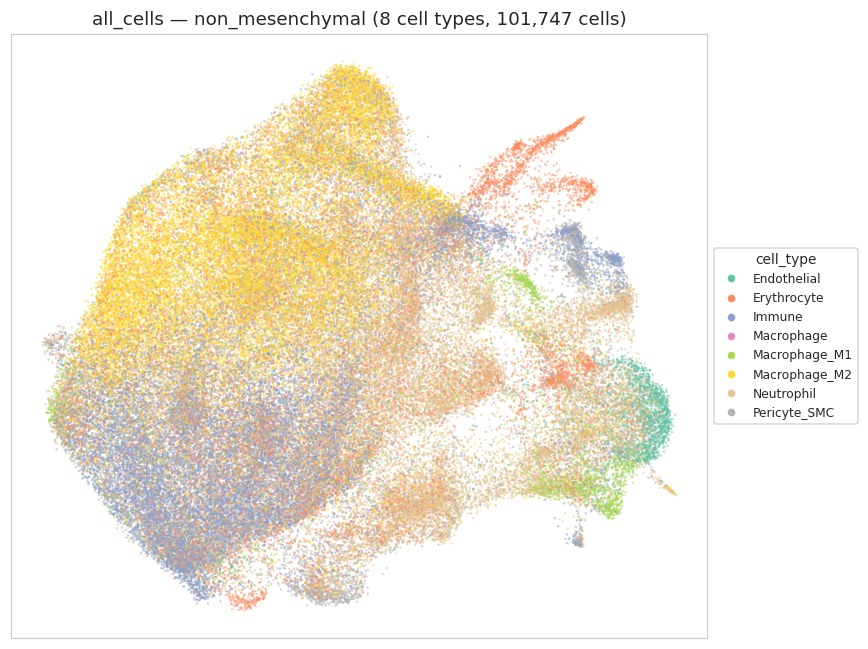

In [9]:
def _plot_tier_celltype_umap(comp_name, comp_path, tier, palette_name='husl'):
    adata = sc.read_h5ad(comp_path, backed='r')
    obs = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    if 'tier' not in obs.columns or 'cell_type' not in obs.columns:
        adata.file.close()
        return False
    mask = (obs['tier'].astype(str) == tier)
    if mask.sum() < 5:
        adata.file.close()
        return False
    umap = adata.obsm['X_umap'][:][mask.values]
    labels = obs.loc[mask, 'cell_type'].astype(str).values
    adata.file.close()

    finite = np.isfinite(umap).all(axis=1)
    umap = umap[finite]; labels = labels[finite]
    if len(umap) < 5:
        return False

    uniq = sorted(set(labels))
    palette = dict(zip(uniq, sns.color_palette(palette_name, max(len(uniq), 8))))
    idx = np.random.RandomState(42).permutation(len(umap))
    colors = [palette[labels[i]] for i in idx]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=0.3, alpha=0.5, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{comp_name} — {tier} ({len(uniq)} cell types, {len(umap):,} cells)',
                 fontsize=12)
    handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[c],
                       markersize=6, label=c) for c in uniq]
    ax.legend(handles=handles, title='cell_type', fontsize=8, title_fontsize=9,
              loc='center left', bbox_to_anchor=(1.0, 0.5),
              ncol=2 if len(uniq) > 12 else 1)
    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    jpeg_bytes = _encode_jpeg(PILImage.open(buf))
    display(Image(data=jpeg_bytes, format='jpeg'))
    return True

for comp_name, comp_path in TV4_COMPARTMENTS.items():
    display(Markdown(f'#### {comp_name}'))
    _plot_tier_celltype_umap(comp_name, comp_path, 'mesenchymal')
    plotted_nm = _plot_tier_celltype_umap(comp_name, comp_path, 'non_mesenchymal',
                                           palette_name='Set2')
    if not plotted_nm:
        print(f'  {comp_name}: no non_mesenchymal tier (or too few cells)')


### §6c — Cell-Type Counts and Confidence (tiered v4)

Per-compartment cell-type tally and confidence distribution. All compartments
now sit at 0.0% unassigned after Module 04 propagation. Note that 12,566 CEP
cells and ~16K NP cells now carry the `Erythrocyte` label — these are real
tissue-prep RBC contamination, flagged for a filter-vs-retain decision before
Module 08.


In [10]:
for comp_name, comp_path in TV4_COMPARTMENTS.items():
    if not comp_path.exists():
        continue
    adata = sc.read_h5ad(comp_path, backed='r')
    obs_df = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    adata.file.close()

    if 'cell_type' not in obs_df.columns:
        continue

    display(Markdown(f'#### {comp_name} — Cell Type Summary (tiered v4)'))

    ct_counts = obs_df['cell_type'].value_counts()
    print(f'{comp_name}: {len(obs_df):,} cells, {ct_counts.shape[0]} cell types')
    print(ct_counts.to_string())
    print()

    if 'cell_type_confidence' in obs_df.columns:
        conf_ct = pd.crosstab(obs_df['cell_type'], obs_df['cell_type_confidence'])
        display(conf_ct.style.set_caption(f'{comp_name} — Confidence per Cell Type (tiered v4)'))

    del obs_df


#### NP — Cell Type Summary (tiered v4)

NP: 262,924 cells, 10 cell types
cell_type
NP_fibrocartilaginous            94597
NP_fibrochondrocyte_chondroid    59650
NP_mature_chondrocyte            33010
Neutrophil                       27880
Macrophage_M2                    20362
Immune                           17282
Macrophage_M1                     3500
Erythrocyte                       3489
Endothelial                       2439
Pericyte_SMC                       715



cell_type_confidence,high,medium
cell_type,,
Endothelial,2439,0
Erythrocyte,3489,0
Immune,0,17282
Macrophage_M1,3500,0
Macrophage_M2,0,20362
NP_fibrocartilaginous,81514,13083
NP_fibrochondrocyte_chondroid,59650,0
NP_mature_chondrocyte,33010,0
Neutrophil,27880,0


#### AF — Cell Type Summary (tiered v4)

AF: 84,617 cells, 7 cell types
cell_type
AF_outer         48836
AF_inner         23769
Immune            5122
Pericyte_SMC      4771
Macrophage_M2     1720
Erythrocyte        370
Endothelial         29



...

CEP: 50,854 cells, 7 cell types
cell_type
CEP_outer                       15557
Erythrocyte                     12635
CEP_hyaline                     12306
CEP_fibrochondrocyte_fibroid     9016
Macrophage_M2                     670
Pericyte_SMC                      638
Neutrophil                         32



cell_type_confidence,high,low,medium
cell_type,,,
CEP_fibrochondrocyte_fibroid,9016,0,0
CEP_hyaline,12306,0,0
CEP_outer,14721,274,562
Erythrocyte,69,0,12566
Macrophage_M2,670,0,0
Neutrophil,32,0,0
Pericyte_SMC,166,472,0


#### all_cells — Cell Type Summary (tiered v4)

all_cells: 410,705 cells, 19 cell types
cell_type
NP_fibrocartilaginous            94597
NP_fibrochondrocyte_chondroid    59650
AF_outer                         48836
NP_mature_chondrocyte            33010
Neutrophil                       27912
AF_inner                         23769
Macrophage_M2                    22752
Immune                           22404
Erythrocyte                      16514
CEP_outer                        15557
CEP_hyaline                      12306
CEP_fibrochondrocyte_fibroid      9016
Chondrocyte_like                  6897
Pericyte_SMC                      6124
Fibrochondrocyte_like             3847
Macrophage_M1                     3500
Endothelial                       2474
Fibroblast_like                   1473
Macrophage                          67



cell_type_confidence,high,low,medium
cell_type,,,
AF_inner,23769,0,0
AF_outer,42637,0,6199
CEP_fibrochondrocyte_fibroid,9016,0,0
CEP_hyaline,12306,0,0
CEP_outer,14721,274,562
Chondrocyte_like,4935,236,1726
Endothelial,2474,0,0
Erythrocyte,3578,0,12936
Fibroblast_like,528,945,0


### §6d — Canonical Marker Expression (tiered v4)

Dot plots of canonical IVD markers grouped by `cell_type` for each
compartment-specific object. PDF versions live in
`results/integration/tiered_v4/annotation_dotplots/`.


#### NP — Canonical Marker Expression (tiered v4)

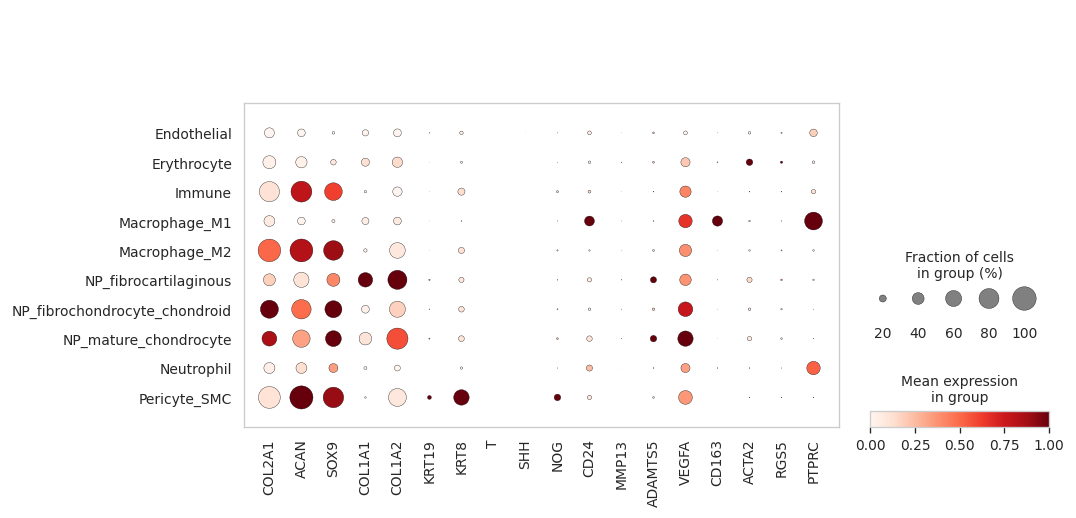

#### AF — Canonical Marker Expression (tiered v4)

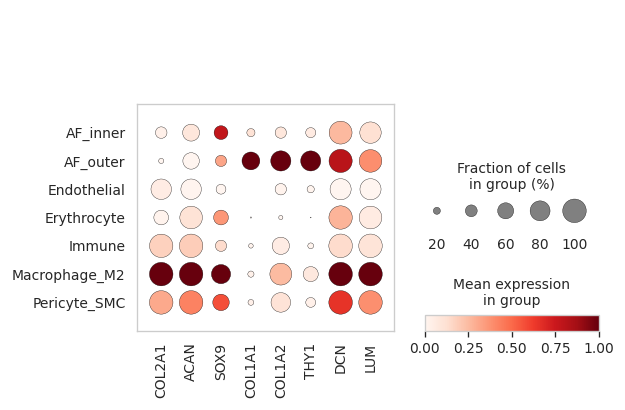

#### CEP — Canonical Marker Expression (tiered v4)

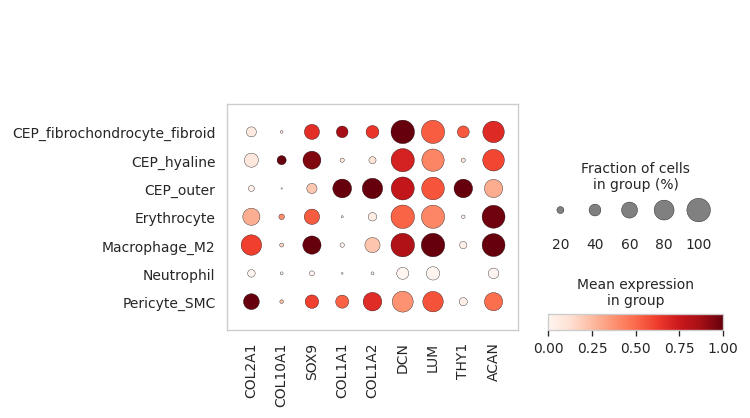

In [11]:
TV4_MARKERS_PER_COMP = {
    'NP': ['COL2A1', 'ACAN', 'SOX9', 'COL1A1', 'COL1A2', 'KRT19', 'KRT8',
           'T', 'SHH', 'NOG', 'CD24', 'MMP13', 'ADAMTS5', 'VEGFA',
           'CD163', 'ACTA2', 'RGS5', 'PTPRC'],
    'AF':  ['COL2A1', 'ACAN', 'SOX9', 'COL1A1', 'COL1A2', 'THY1', 'DCN', 'LUM'],
    'CEP': ['COL2A1', 'COL10A1', 'SOX9', 'COL1A1', 'COL1A2', 'DCN', 'LUM', 'THY1', 'ACAN'],
}

for comp_name in ['NP', 'AF', 'CEP']:
    comp_path = TV4_COMPARTMENTS[comp_name]
    if not comp_path.exists():
        continue
    markers = TV4_MARKERS_PER_COMP.get(comp_name, [])
    if not markers:
        continue

    adata = sc.read_h5ad(comp_path)
    if 'cell_type' not in adata.obs.columns:
        del adata
        continue

    available = [g for g in markers if g in adata.var_names]
    if not available:
        del adata
        continue

    display(Markdown(f'#### {comp_name} — Canonical Marker Expression (tiered v4)'))
    sc.pl.dotplot(adata, var_names=available, groupby='cell_type',
                  standard_scale='var', show=True)
    del adata


### §6e — Per-Tier Marker Tables (tiered v4)

The tiered v4 annotator emits two flavors of marker table:
- `*_<tier>_markers.tsv` — markers separating coarse types within a compartment×tier.
- `*_<tier>_<CoarseType>_within_markers.tsv` — markers separating fine types
  within a single coarse group (stage-2 annotation, only present where the coarse
  group contains multiple fine types).


In [12]:
tv4_marker_files = sorted(TV4_MARKER_DIR.glob('*.tsv'))
print(f'Tiered v4 marker tables: {len(tv4_marker_files)} files\n')
for f in tv4_marker_files:
    print(f'  {f.name}')


Tiered v4 marker tables: 13 files

  AF_mesenchymal_Chondrocyte_like_within_markers.tsv
  AF_mesenchymal_Fibroblast_like_within_markers.tsv
  AF_mesenchymal_markers.tsv
  AF_non_mesenchymal_Macrophage_within_markers.tsv
  AF_non_mesenchymal_markers.tsv
  CEP_mesenchymal_Chondrocyte_like_within_markers.tsv
  CEP_mesenchymal_markers.tsv
  CEP_non_mesenchymal_markers.tsv
  NP_mesenchymal_Fibroblast_like_within_markers.tsv
  NP_mesenchymal_Fibrochondrocyte_like_within_markers.tsv
  NP_mesenchymal_markers.tsv
  NP_non_mesenchymal_Macrophage_within_markers.tsv
  NP_non_mesenchymal_markers.tsv


### §6g — Sub-state UMAPs (cell_subtype, mesenchymal tier)

Stage 3 annotation (overlap-based scoring against `SUBSTATE_PANELS`) labels
each cell with `cell_subtype = <cell_type>_<sub_state>`, where sub-state is
one of `proliferating`, `inflammatory`, `stressed`, `matrix_active`,
`migratory`, or `homeostatic` (fallback when no panel overlaps the cluster's
top-50 rank_genes_groups markers by ≥3 genes). A contamination flag
(`_endothelial_admixed`) fires when ≥2 of CD34/EMCN/AQP1 are in the
cluster's top markers.

Non-mesenchymal cells skip Stage 3 — their existing fine labels
(`Macrophage_M1/M2`, `Neutrophil`, `Erythrocyte`, etc.) are already specific
enough — so `cell_subtype = cell_type` for those cells. The UMAPs below show
the mesenchymal tier only.


#### NP

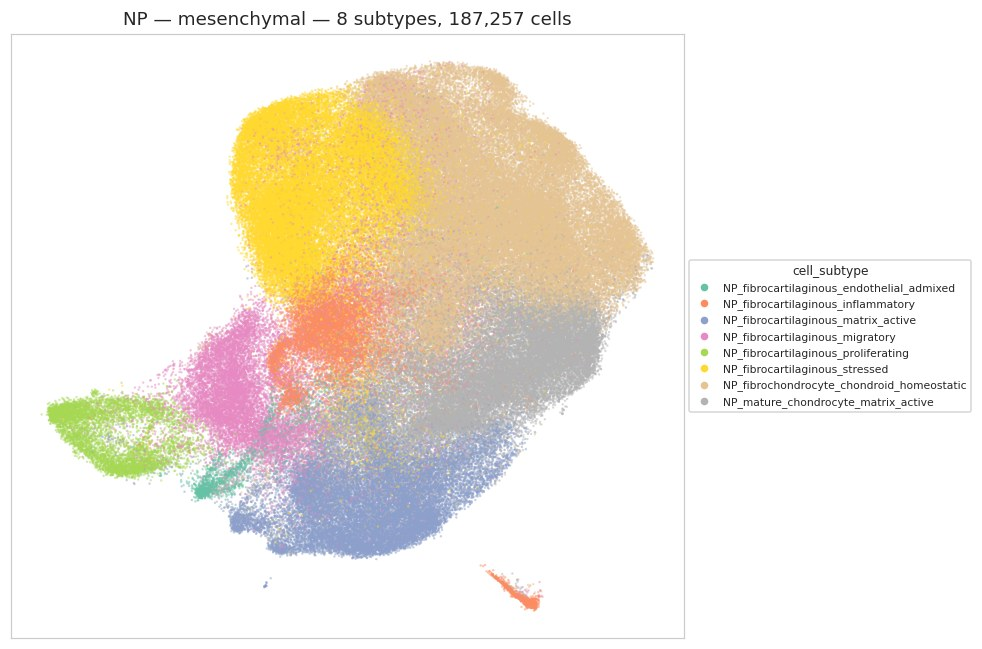

#### AF

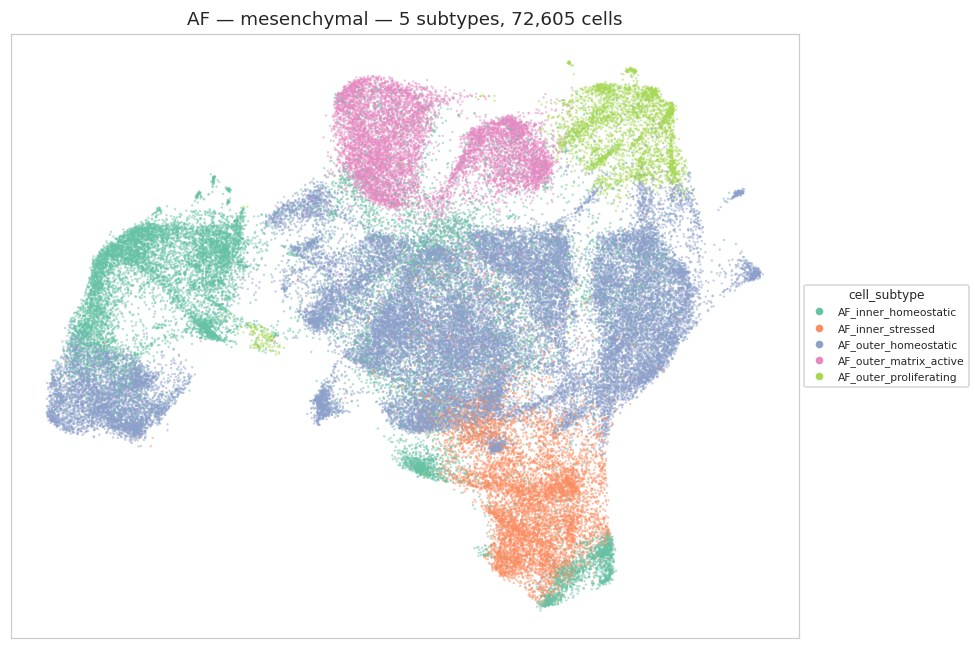

#### CEP

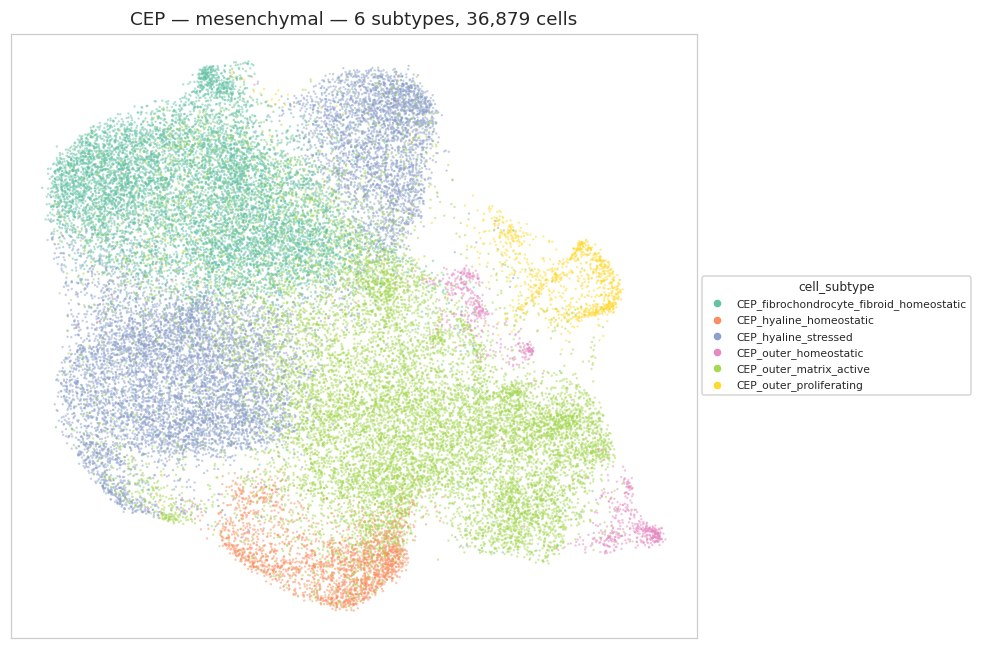

#### all_cells

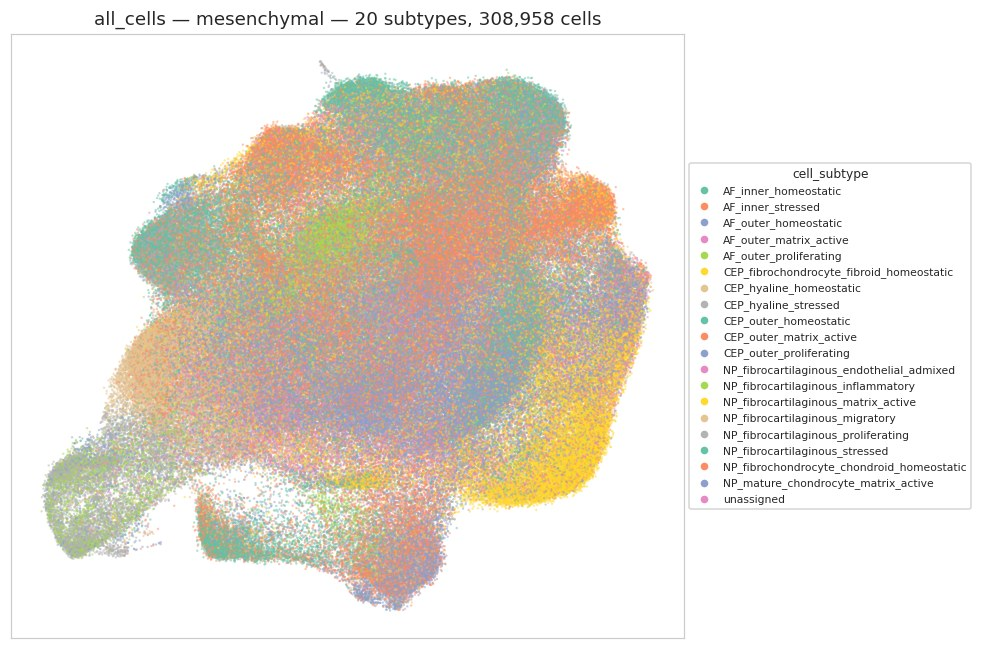

In [13]:
def _plot_tier_subtype_umap(comp_name, comp_path, tier='mesenchymal', palette_name='Set2'):
    adata = sc.read_h5ad(comp_path, backed='r')
    obs = adata.obs.to_memory() if hasattr(adata.obs, 'to_memory') else adata.obs.copy()
    if 'tier' not in obs.columns or 'cell_subtype' not in obs.columns:
        adata.file.close()
        return False
    mask = (obs['tier'].astype(str) == tier)
    if mask.sum() < 5:
        adata.file.close()
        return False
    umap = adata.obsm['X_umap'][:][mask.values]
    labels = obs.loc[mask, 'cell_subtype'].astype(str).values
    adata.file.close()

    finite = np.isfinite(umap).all(axis=1)
    umap = umap[finite]; labels = labels[finite]
    if len(umap) < 5:
        return False

    uniq = sorted(set(labels))
    palette = dict(zip(uniq, sns.color_palette(palette_name, max(len(uniq), 8))))
    idx = np.random.RandomState(42).permutation(len(umap))
    colors = [palette[labels[i]] for i in idx]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors, s=0.3, alpha=0.5, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{comp_name} — mesenchymal — {len(uniq)} subtypes, {len(umap):,} cells',
                 fontsize=12)
    handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[c],
                       markersize=6, label=c) for c in uniq]
    ax.legend(handles=handles, title='cell_subtype', fontsize=7, title_fontsize=8,
              loc='center left', bbox_to_anchor=(1.0, 0.5),
              ncol=1)
    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    jpeg_bytes = _encode_jpeg(PILImage.open(buf))
    display(Image(data=jpeg_bytes, format='jpeg'))
    return True

for comp_name, comp_path in TV4_COMPARTMENTS.items():
    display(Markdown(f'#### {comp_name}'))
    _plot_tier_subtype_umap(comp_name, comp_path, 'mesenchymal')


### §6f — Items for human checkpoint review (2026-05-22)

All validator warnings from the 2026-05-15 run are resolved (NP unassigned
6.6 → 0.0 %; CEP CellTypist now runs; the 2026-05-22 v1 CEP unassigned
24.7 % spike is also resolved). The remaining checkpoint items are scientific
decisions, not pipeline issues:

1. **RBC contamination filter.** Module 04 + Module 07 now correctly call
   12,566 CEP cells (24.7 % of CEP) and ~16K NP cells `Erythrocyte` via the
   `HBB / HBA1 / HBA2 / GYPA` top-10th-percentile rule. CEP samples sit next
   to vascularized bone, so heavy RBC contamination is expected. Pseudobulk
   DE on RBCs is meaningless and they can distort proportion analyses.
   Decision: filter these cells out before Module 08, retain them as a
   contamination-tracking marker, or keep with caveats?
2. **CellTypist concordance (NP 4/9, AF 2/7, CEP 3/10).** Driven by two
   systematic mismaps in `Immune_All_Low.pkl`: (a) neutrophils called as
   classical monocytes (the model has no neutrophil class); (b) pericytes /
   macrophages with strong matrix signatures called as fibroblasts. De novo
   marker-based calls are the trustworthy labels in these cases.
3. **`Immune` as a catch-all (Module 04 propagation).** Clusters labeled
   `Immune` rather than a specific subtype (Macrophage / Neutrophil / T_cell
   / etc.) are those where the fine-panel scoring did not fire — typically
   ribosomal-dominant naive/resting lymphocytes (NP cluster 1, 17,282 cells;
   AF cluster 0, 5,122 cells). Decision: leave as `Immune`, or expand fine
   panels (e.g., resting-T-cell rule with CD3D + low-activation markers)
   for one more iteration of Module 07?
4. **`NP_fibrocartilaginous_endothelial_admixed` (1,831 cells, NP non-mes
   cluster 8).** Mes-tier cluster carrying strong endothelial markers
   (CD34/EMCN/AQP1) — flagged for review rather than relabeled, as agreed.
   Module 04 routed these cells to the mes tier but the integration
   embedding is consistent with endothelial identity. Likely candidate for
   filtering before Module 08 if treated alongside the RBC contamination.
5. **Coarse-type naming convention (deferred from 2026-05-15).** Compartment-
   specific labels (`NP_fibrocartilaginous`, `AF_inner`, `EP_hyaline`) coexist
   with generic labels (`Fibroblast_like`, `Chondrocyte_like`) in the
   `all_cells` object. Harmonize before Module 08 pseudobulk?
6. **Module 08 grouping decision (2026-05-22).** Primary pseudobulk DE will
   run on `cell_type` (collapsed, ~17 types) for statistical power and
   v5 cross-version comparability. `cell_subtype` (~27 across all_cells) is
   the supplementary descriptive lens — used for composition tests and
   within-cell-type characterization (Module 09).


## Status — Module 07 tiered v4 complete (2026-05-22 rerun + Stage 3 sub-states)

### Summary
- De novo cell-type annotation via stage-1 coarse markers + stage-2 fine
  markers + **stage-3 sub-state markers** (mesenchymal tier only); CellTypist
  as secondary validator for non-mesenchymal subtypes.
- **NP 10 · AF 7 · CEP 7 · all_cells 18** cell types (collapsed).
- **NP 15 · AF 10 · CEP 10 · all_cells 27** cell sub-states (overlap-based
  scoring against `SUBSTATE_PANELS`; min_overlap=3 with the cluster's top-50
  rank_genes_groups markers).
- **1,831 cells flagged `_endothelial_admixed`** (NP non-mes cluster 8) —
  mes-tier cluster carrying strong endothelial markers; held for review.
- **0.0 % unassigned** across all four compartments.
- CellTypist concordances: NP 4/9, AF 2/7, CEP 3/10 — disagreements driven
  by `Immune_All_Low.pkl` mismaps, not panel failures.
- Annotated h5ads at `data/integrated/tiered_v4/{NP,AF,CEP,all_cells}.h5ad`.

### Module 08 plan (agreed 2026-05-22)
- **Primary DE grouping:** `cell_type` (collapsed). Cleaner statistical
  power, comparable to v5, and the unit the manuscript figures will use.
- **Composition (propeller):** both `cell_type` and `cell_subtype` — the
  finer grouping often reveals proportion changes the coarser one masks.
- **Sub-state contribution:** for each cell_type DE result, note which
  sub-state drove the signal as a post-hoc descriptive annotation.

### Human checkpoint (see §6f)
- RBC contamination filter decision (CEP 12,566 + NP ~16K cells).
- `_endothelial_admixed` cluster: filter alongside RBCs, or retain with
  caveats?
- `Immune` catch-all vs finer subtypes for naive/resting lymphocytes.
- Coarse-type naming convention (compartment-specific vs generic).

### Next steps (if checkpoint clears)
- Module 08: pseudobulk DE on `cell_type` (primary) + composition on both
  `cell_type` and `cell_subtype`.
- Module 09–12 to follow once Module 08 lands.
